# Session 1 Exercise: Building and Evaluating a Single-Layer Perceptron

**Introduction to Machine Learning — Session 1: Foundations & Parametric Classifiers I**

In this notebook you will:

1. Generate a small, linearly separable 2D dataset
2. Split the data into train / validation / test sets
3. Implement a single-layer perceptron **from scratch** (no ML libraries for the model itself)
4. Train the perceptron and evaluate it with a confusion matrix, precision, and recall
5. Visualise the decision boundary
6. Evaluate on the validation set
7. Plot an ROC curve
8. Shift the decision threshold and watch precision and recall trade off against each other
9. Choose a new threshold and perform validation on the **test** set

Work through the cells top to bottom. Cells marked **`# TODO`** are for you to complete — everything else is provided so you can focus on the concepts.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.close('all')
%matplotlib inline

## 1. Generate a toy dataset

We'll create two clusters of 2D points — think of them as two classes of sensor readings
(e.g. "obstacle" vs. "no obstacle"). The clusters are linearly separable, meaning a single
straight line can (mostly) tell them apart — exactly the kind of problem a single-layer
perceptron is built for.

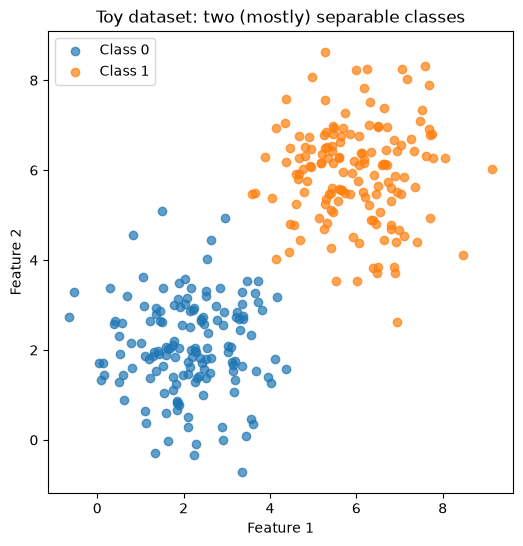

In [3]:
def make_dataset(n_per_class=150, noise=1.0):
    class0 = np.random.randn(n_per_class, 2) * noise + np.array([2, 2])
    class1 = np.random.randn(n_per_class, 2) * noise + np.array([6, 6])

    X = np.vstack([class0, class1])
    y = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

    # Shuffle so classes aren't grouped in order
    idx = np.random.permutation(len(X))
    return X[idx], y[idx]

X, y = make_dataset()

plt.figure(figsize=(6, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0", alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1", alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Toy dataset: two (mostly) separable classes")
plt.legend()
plt.show()

## 2. Train / validation / test split

Before training anything, split the data into three parts:

- **Train** (60%) — used to fit the perceptron's weights
- **Validation** (20%) — used if you want to tune anything (e.g. learning rate, threshold)
- **Test** (20%) — touched only once, at the very end, as a final honest check

**`# TODO`**: complete the `split_data` function below.

In [4]:
def split_data(X, y, train_frac=0.6, val_frac=0.2):
    """Split X, y into train/val/test sets according to the given fractions."""
    n = len(X)
    idx = np.random.permutation(n)

    #--------------
    # TODO: compute the number of training and validation examples
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    #--------------

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]

    return (X[train_idx], y[train_idx],
            X[val_idx], y[val_idx],
            X[test_idx], y[test_idx])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y)

print("Train size:", len(X_train))
print("Val size:  ", len(X_val))
print("Test size: ", len(X_test))

Train size: 180
Val size:   60
Test size:  60


## 3. Implement the single-layer perceptron

Recall the model from lecture:

$$z = w_1 x_1 + w_2 x_2 + b$$

$$\hat{y} = 1 \text{ if } z \geq 0 \text{ else } 0$$

Training rule (perceptron learning rule), applied one example at a time:

$$w \leftarrow w + \eta (y - \hat{y}) x$$
$$b \leftarrow b + \eta (y - \hat{y})$$

where $\eta$ (eta) is the learning rate.

**`# TODO`**: complete the `predict` and `fit` methods below.

In [5]:
class Perceptron:
    def __init__(self, n_features, learning_rate=0.1):
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.lr = learning_rate

    def net_input(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        #------------------
        # TODO: return classification result y_hat
        z = self.net_input(X)

        return np.where(z >= 0, 1, 0)
        #------------------


    def fit(self, X, y, epochs=50):
        history = []
        for epoch in range(epochs):

            #------------------
            # TODO: compute the prediction for this single example
            y_hat = self.predict(X)

            #TODO: count number of errors
            no_errors = np.sum(y != y_hat)

            # TODO: compute the update amount: lr * (y - y_hat)
            update = self.lr * (y - y_hat)
            #------------------
            # TODO: the end update is a sum of differences on all points times xi for w, and just the sum for b
            self.w += np.sum(update[:, np.newaxis] * X, axis=0)
            self.b += np.sum(update)
             #------------------
            history.append(no_errors)
        return history

## 4. Train the perceptron

Run the cell below once your `Perceptron` class is complete. The plot shows how many
mistakes the perceptron made on the training set each epoch — it should trend toward zero
if the data is linearly separable.

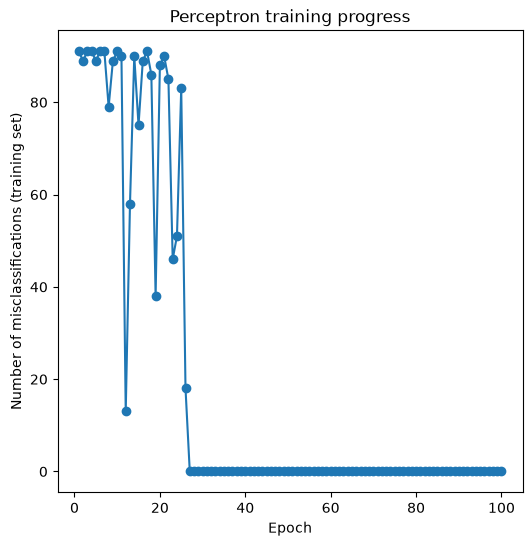

Learned weights: [11.00803625 10.813923  ] -87.69999999999999


In [6]:
model = Perceptron(n_features=2, learning_rate=0.1)
history = model.fit(X_train, y_train, epochs=100)

plt.figure(figsize=(6, 6))
plt.plot(range(1, len(history) + 1), history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Number of misclassifications (training set)")
plt.title("Perceptron training progress")
plt.show()

print("Learned weights:", model.w, model.b)


## 5. Visualise the decision boundary

This plots the line the perceptron learned, on top of the training data.

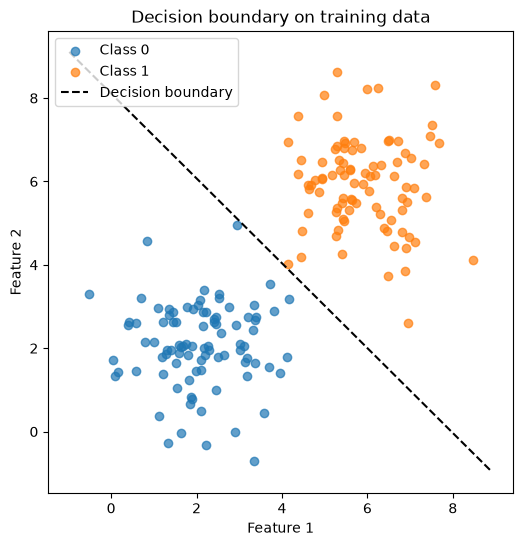

In [7]:
def plot_decision_boundary(model, X, y, title="Decision boundary"):
    plt.figure(figsize=(6, 6))
    plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0", alpha=0.7)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1", alpha=0.7)

    x_vals = np.array(plt.gca().get_xlim())
    if model.w[1] != 0:
        y_vals = -(model.w[0] * x_vals + model.b) / model.w[1]
        plt.plot(x_vals, y_vals, "k--", label="Decision boundary")

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend()
    plt.show()

plot_decision_boundary(model, X_train, y_train, title="Decision boundary on training data")

## 6. Evaluate on the validation set

Now we look at the validation set. Build the confusion matrix by hand.

Recall:

- **True Positive (TP)**: predicted 1, actually 1
- **False Positive (FP)**: predicted 1, actually 0
- **True Negative (TN)**: predicted 0, actually 0
- **False Negative (FN)**: predicted 0, actually 1

**`# TODO`**: complete `confusion_counts`, then `precision` and `recall`.

In [13]:
def confusion_counts(y_true, y_pred):
    #------------------
    # TODO: compute TP, FP, TN, FN using boolean masks
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    #------------------

    return tp, fp, tn, fn

y_val_pred = model.predict(X_val)
tp, fp, tn, fn = confusion_counts(y_val, y_val_pred)

print(f"TP={tp}  FP={fp}")
print(f"FN={fn}  TN={tn}")

confusion_matrix = np.array([[tn, fp],
                              [fn, tp]])
print("\nConfusion matrix [rows=actual, cols=predicted], order=[0,1]:")
print(confusion_matrix)

TP=33  FP=0
FN=0  TN=27

Confusion matrix [rows=actual, cols=predicted], order=[0,1]:
[[27  0]
 [ 0 33]]


In [9]:
def precision(tp, fp):
    #------------------
    # TODO: return tp / (tp + fp), guarding against division by zero
    return tp / (tp + fp)
    #------------------

def recall(tp, fn):
    #------------------
    # TODO: return tp / (tp + fn), guarding against division by zero
    return tp / (tp + fn)
    #------------------

prec = precision(tp, fp)
rec = recall(tp, fn)
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")

Precision: 1.000
Recall:    1.000


## 7. ROC curve

The perceptron as written gives a hard 0/1 decision, but under the hood it's really
thresholding a continuous score (`net_input`) at zero. To draw an ROC curve, sweep that
threshold across a range of values and, at each one, compute the true positive rate (TPR,
same as recall) and false positive rate (FPR).

$$\text{TPR} = \frac{TP}{TP + FN} \qquad \text{FPR} = \frac{FP}{FP + TN}$$

**`# TODO`**: complete the loop below.

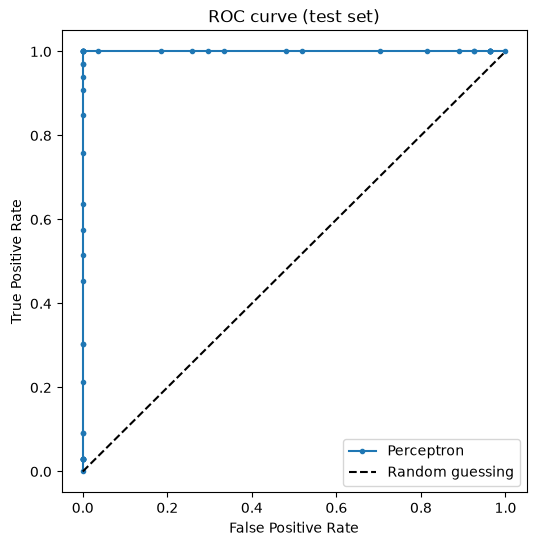

In [10]:
def roc_points(model, X, y, n_thresholds=50):
    scores = model.net_input(X)
    thresholds = np.linspace(scores.min() - 1, scores.max() + 1, n_thresholds)

    tpr_list, fpr_list = [], []
    for t in thresholds:
        #------------------
        # TODO: predict 1 where scores >= t, else 0
        y_pred_t = np.where(scores >= t, 1, 0)

        tp = np.sum((y == 1) & (y_pred_t == 1))
        fp = np.sum((y == 0) & (y_pred_t == 1))
        tn = np.sum((y == 0) & (y_pred_t == 0))
        fn = np.sum((y == 1) & (y_pred_t == 0))

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        #------------------

        tpr_list.append(tpr)
        fpr_list.append(fpr)

    return np.array(fpr_list), np.array(tpr_list)

fpr, tpr = roc_points(model, X_val, y_val)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, marker=".", label="Perceptron")
plt.plot([0, 1], [0, 1], "k--", label="Random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve (test set)")
plt.legend()
plt.show()

## 8. Shift the threshold, watch precision and recall trade off

Instead of thresholding at zero, try a few different thresholds on `net_input` and see how
precision and recall respond. This is the same "smoke detector" trade-off from lecture:
a lower threshold catches more true positives (higher recall) but also raises more false
alarms (lower precision).

**`# TODO`**: pick some threshold values and print precision/recall at each.

threshold=-20.0   precision=0.846   recall=1.000
threshold=-10.0   precision=1.000   recall=1.000
threshold=-5.0   precision=1.000   recall=1.000
threshold=+0.0   precision=1.000   recall=1.000
threshold=+5.0   precision=1.000   recall=0.970
threshold=+10.0   precision=1.000   recall=0.970
threshold=+20.0   precision=1.000   recall=0.758


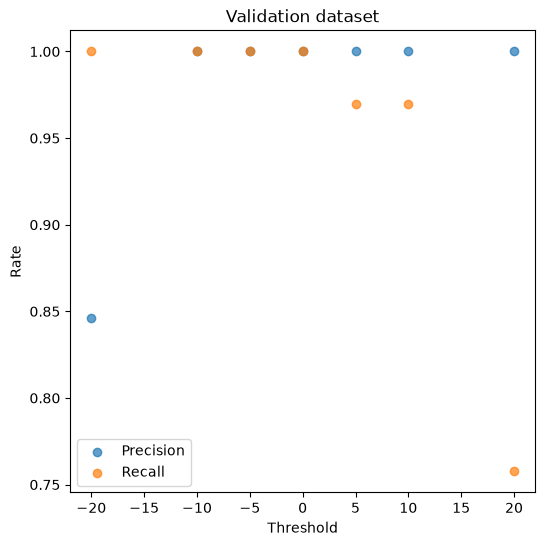

In [11]:
#------------------
# TODO: try a few threshold values, e.g. from -20 to 20
thresholds_to_try = [-20, -10, -5, 0, 5, 10, 20]
#------------------

precision_list = []
recall_list = []

scores = model.net_input(X_val)
for t in thresholds_to_try:
    y_pred_t = (scores >= t).astype(int)
    tp_t, fp_t, tn_t, fn_t = confusion_counts(y_val, y_pred_t)
    p = precision(tp_t, fp_t)
    r = recall(tp_t, fn_t)
    precision_list.append(p)
    recall_list.append(r)
    print(f"threshold={t:+.1f}   precision={p:.3f}   recall={r:.3f}")

precisions = np.array(precision_list)
recalls = np.array(recall_list)
thresholds = np.array(thresholds_to_try)

plt.figure(figsize=(6, 6))
plt.scatter(thresholds, precisions, label="Precision", alpha=0.7)
plt.scatter(thresholds, recalls, label="Recall", alpha=0.7)
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("Validation dataset")
plt.legend()
plt.show()

## 9. Stretch task: Choose a threshold and run the validation again - for test dataset

1. Predict classes for test dataset with the changed threshold (note that the method for Perceptron class doesn't include the threshold change option!)
2. Compute Confusion Matrix
2. Calculate Precision and Recall
3. Print results

In [ ]:
# TODO: all
